Servicios en grafo: 78
Aristas: 491
Servicios en catalogo: 160
shape: (15, 3)
┌────────────┬───────────────────┬───────────────┐
│ service    ┆ centralidad_score ┆ nivel         │
│ ---        ┆ ---               ┆ ---           │
│ str        ┆ f64               ┆ str           │
╞════════════╪═══════════════════╪═══════════════╡
│ S3         ┆ 1.0               ┆ Fundamental   │
│ Lambda     ┆ 0.837481          ┆ Fundamental   │
│ EC2        ┆ 0.597545          ┆ Fundamental   │
│ DynamoDB   ┆ 0.584912          ┆ Fundamental   │
│ ApiGateway ┆ 0.479511          ┆ Integrador    │
│ …          ┆ …                 ┆ …             │
│ SageMaker  ┆ 0.294461          ┆ Especializado │
│ Athena     ┆ 0.282564          ┆ Especializado │
│ SNS        ┆ 0.264696          ┆ Especializado │
│ Aurora     ┆ 0.26              ┆ Especializado │
│ CloudFront ┆ 0.259672          ┆ Especializado │
└────────────┴───────────────────┴───────────────┘
Detectando servicios toxicos-centrales (pool nucleo)
To

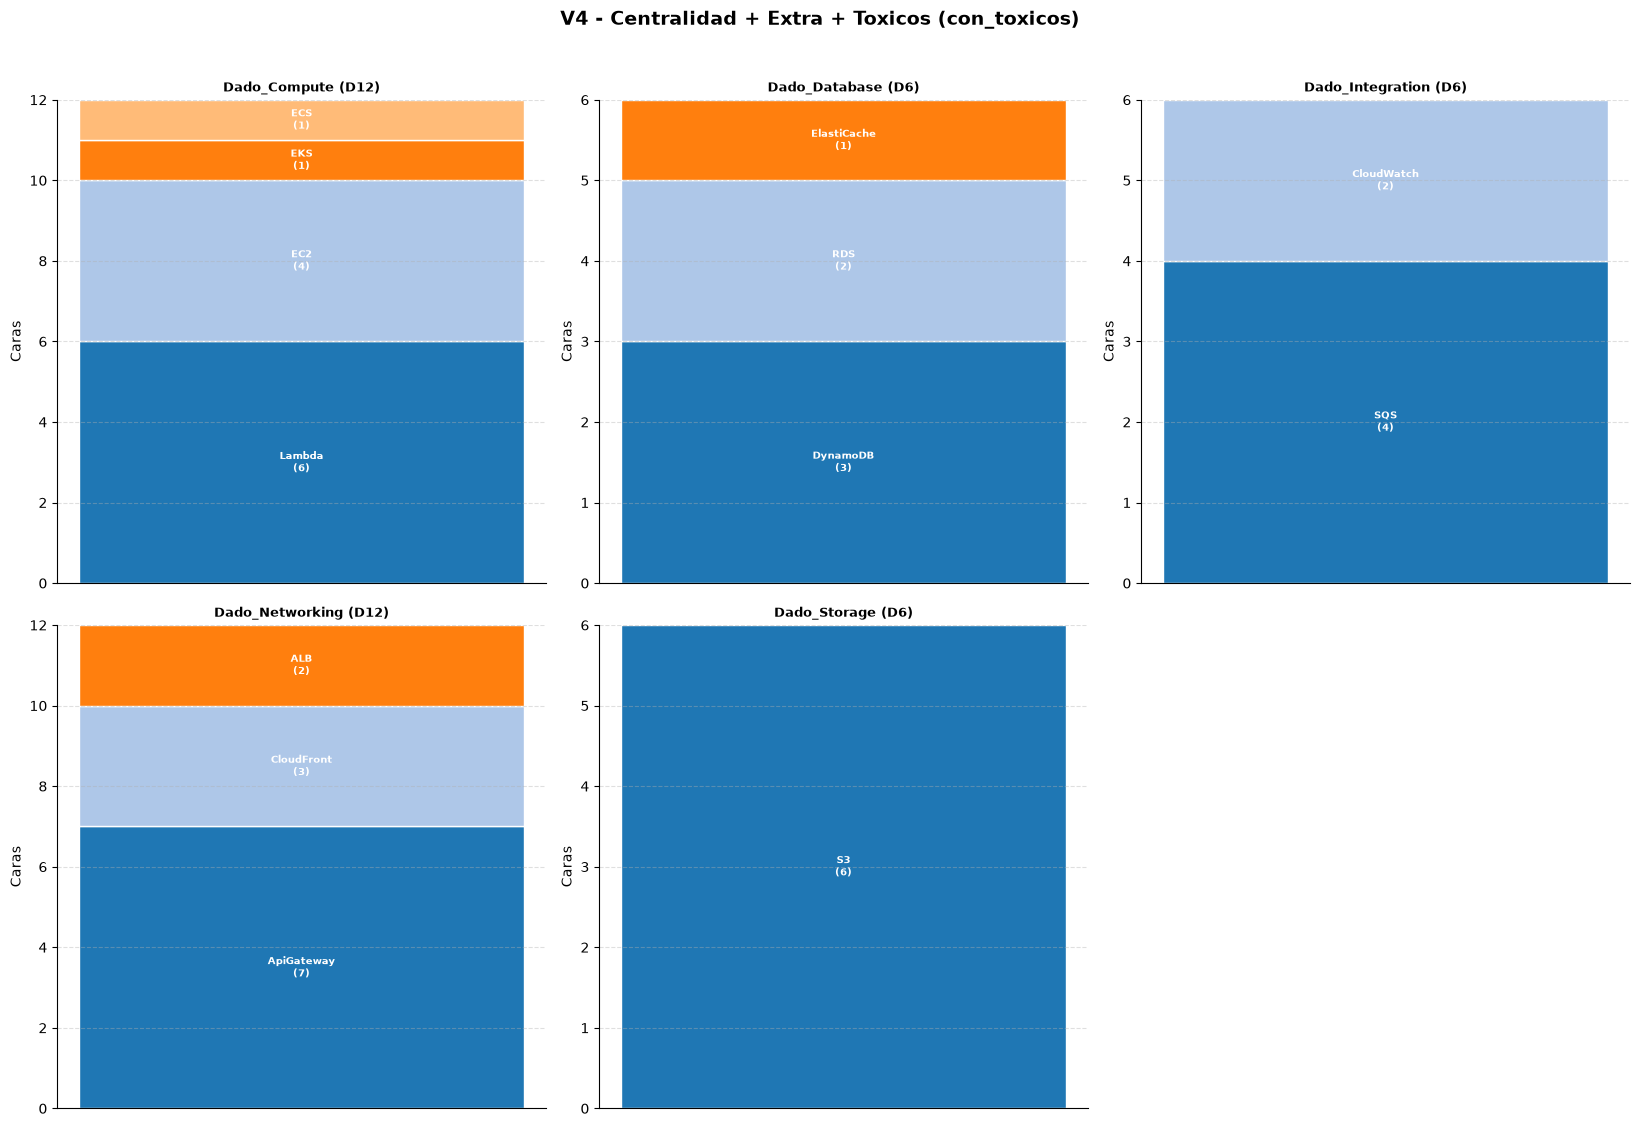

V4 - Centralidad + Extra + Toxicos (con_toxicos)
Repetidos: 0 (0.0%)
Incompatibles: 0 (0.0%)
Unicas: 67 de 1000

>>> Ninguna tirada rompio la regla de incompatibilidad. OK.

Top 10 mas comunes:
shape: (10, 3)
┌──────────────────────────────────────────────────┬────────────┬──────────────┐
│ arquitectura                                     ┆ frecuencia ┆ porcentaje_% │
│ ---                                              ┆ ---        ┆ ---          │
│ str                                              ┆ u32        ┆ f64          │
╞══════════════════════════════════════════════════╪════════════╪══════════════╡
│ ApiGateway | DynamoDB | Lambda | S3 | SQS        ┆ 93         ┆ 9.3          │
│ ApiGateway | Lambda | RDS | S3 | SQS             ┆ 68         ┆ 6.8          │
│ ApiGateway | DynamoDB | EC2 | S3 | SQS           ┆ 62         ┆ 6.2          │
│ CloudFront | DynamoDB | Lambda | S3 | SQS        ┆ 52         ┆ 5.2          │
│ ApiGateway | CloudWatch | DynamoDB | Lambda | S3 ┆ 47       

In [20]:
import math
import pickle
import itertools
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
})

np.random.seed(420)
## 1. Carga de Datos

class CloudscapeDataset:
    def __init__(self, df_architectures, df_nodes, df_edges, graphs):
        self.architectures = df_architectures
        self.nodes = df_nodes
        self.edges = df_edges
        self.graphs = graphs


BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
SERVICES_CSV = DATA_DIR / "services.csv"
BUNDLE_PATH = BASE_DIR / "output_analytics" / "cloudscape_pipeline_bundle.pkl"

if not BUNDLE_PATH.exists():
    raise FileNotFoundError(f"No se encontro el bundle en {BUNDLE_PATH}")

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

df_services_master: pl.DataFrame = bundle["df_services_master"]
df_cooccurrences: pl.DataFrame = bundle["df_cooccurrences"]
df_transitions = bundle.get("df_transitions")
G_cooc_master: nx.Graph = bundle["G_cooc_master"]

print(f"Servicios en grafo: {G_cooc_master.number_of_nodes()}")
print(f"Aristas: {G_cooc_master.number_of_edges()}")
print(f"Servicios en catalogo: {df_services_master.height}")
## 2. Utilidades Comunes

df_services_cat = pl.read_csv(SERVICES_CSV).select(['name', 'aws_product_categories'])
cat_map_raw = {}
for row in df_services_cat.iter_rows(named=True):
    cats = [c.strip() for c in row['aws_product_categories'].split(',')] if row['aws_product_categories'] else []
    cat_map_raw[row['name']] = cats

GROUP_MAPPING = {
    'Compute': ['Compute'],
    'Storage': ['Storage'],
    'Networking': ['Networking and Content Delivery'],
    'Integration': ['Application Integration'],
    'Analytics': ['Analytics'],
    'Security': ['Security Identity and Compliance'],
    'Management': ['Management and Governance'],
    'IoT': ['IoT'],
    'Media': ['Media Services'],
    'Developer': ['Developer Tools'],
    'Database': ['Database'],
    'ML': ['ML'],
    'Other': [],
}


def get_service_category(service: str) -> str:
    cats = cat_map_raw.get(service, [])
    for group, keywords in GROUP_MAPPING.items():
        for kw in keywords:
            if any(kw in c for c in cats):
                return group
    cap_rows = df_services_master.filter(pl.col('service') == service)['capability']
    cap = cap_rows.first() if len(cap_rows) > 0 else None
    return {
        'compute': 'Compute', 'storage': 'Storage',
        'networking': 'Networking', 'integration': 'Integration',
    }.get(cap, 'Other')


POPULARIDAD = {
    row['service']: row['num_architectures']
    for row in df_services_master.iter_rows(named=True)
}
PESO_BASE = {
    row['service']: row['base_prob_weight']
    for row in df_services_master.iter_rows(named=True)
}


def popularidad(servicio: str) -> int:
    return POPULARIDAD.get(servicio, 0)


def peso(servicio: str) -> float:
    return PESO_BASE.get(servicio, 0.0)


def son_incompatibles(s1: str, s2: str, G: nx.Graph = None) -> bool:
    if G is None:
        G = G_cooc_master
    if s1 == s2:
        return False
    if not G.has_node(s1) or not G.has_node(s2):
        return True
    return not G.has_edge(s1, s2)


def hay_conflicto_interno(servicio: str, miembros: list, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    for m in miembros:
        if son_incompatibles(servicio, m, G):
            return m
    return None


def hay_conflicto_con_otros_dados(servicio: str, dados: dict, excluir=None, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    for dado_id, miembros in dados.items():
        if dado_id == excluir:
            continue
        conflicto = hay_conflicto_interno(servicio, miembros, G)
        if conflicto:
            return (dado_id, conflicto)
    return None


def tasa_incompatibilidad(servicio: str, grupo: list, G: nx.Graph = None) -> float:
    if G is None:
        G = G_cooc_master
    if not grupo:
        return 0.0
    choques = sum(1 for o in grupo if son_incompatibles(servicio, o, G))
    return choques / len(grupo)


def encontrar_conflictos_globales(dados: dict, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    conflictos = []
    ids = list(dados.keys())
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            for s1 in dados[ids[i]]:
                for s2 in dados[ids[j]]:
                    if son_incompatibles(s1, s2, G):
                        conflictos.append((ids[i], s1, ids[j], s2))
    return conflictos


## 3. Centralidad


def calcular_centralidad(G: nx.Graph = None) -> pl.DataFrame:
    if G is None:
        G = G_cooc_master
    pagerank = nx.pagerank(G, weight='weight')
    degree_centrality = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G, weight='weight')
    closeness = nx.closeness_centrality(G, distance='weight')
    try:
        eigenvector = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')

    filas = []
    for s in G.nodes():
        filas.append({
            'service': s,
            'num_architectures': popularidad(s),
            'degree': G.degree(s),
            'pagerank': pagerank.get(s, 0),
            'degree_centrality': degree_centrality.get(s, 0),
            'betweenness': betweenness.get(s, 0),
            'closeness': closeness.get(s, 0),
            'eigenvector': eigenvector.get(s, 0),
        })
    df = pl.DataFrame(filas)
    for col in ['pagerank', 'degree_centrality', 'betweenness', 'closeness', 'eigenvector']:
        max_val = df[col].max()
        if max_val and max_val > 0:
            df = df.with_columns((pl.col(col) / max_val).alias(col))

    df = df.with_columns(
        (0.30 * pl.col('pagerank') + 0.25 * pl.col('degree_centrality') + 0.20 * pl.col('betweenness') +
         0.15 * pl.col('eigenvector') + 0.10 * pl.col('closeness')).alias('centralidad_score')
    )
    df = df.with_columns(
        pl.when(pl.col('centralidad_score') > 0.5).then(pl.lit('Fundamental'))
        .when(pl.col('centralidad_score') > 0.3).then(pl.lit('Integrador'))
        .otherwise(pl.lit('Especializado')).alias('nivel')
    )
    return df.sort('centralidad_score', descending=True)


df_centralidad = calcular_centralidad(G_cooc_master)

CENTRALIDAD = {
    row['service']: row['centralidad_score']
    for row in df_centralidad.iter_rows(named=True)
}


def centralidad(servicio: str) -> float:
    return CENTRALIDAD.get(servicio, 0.0)


print(df_centralidad.select(['service', 'centralidad_score', 'nivel']).head(15))
## 4. Metodo V4

### 4.1 Deteccion de toxicos-centrales
def identificar_toxicos_centrales(df_centralidad: pl.DataFrame, pool_total: list,
                                  G: nx.Graph = None,
                                  umbral_centralidad: float = 0.3,
                                  umbral_toxicidad: float = 0.5,
                                  verbose: bool = True) -> list:
    """
    Un servicio es 'toxico-central' si:
      - su centralidad_score >= umbral_centralidad (por defecto, nivel Integrador o Fundamental)
      - su tasa de incompatibilidad contra el resto del pool >= umbral_toxicidad

    Los umbrales son arbitrarios (igual que en V3): 0.3 coincide con el corte de
    'Integrador' que ya usa calcular_centralidad, y 0.5 significa "choca con la
    mitad o mas del catalogo".
    """
    if G is None:
        G = G_cooc_master

    candidatos = df_centralidad.filter(
        (pl.col('service').is_in(pool_total)) &
        (pl.col('centralidad_score') >= umbral_centralidad)
    )

    toxicos = []
    for row in candidatos.iter_rows(named=True):
        s = row['service']
        resto = [o for o in pool_total if o != s]
        tasa = tasa_incompatibilidad(s, resto, G)
        if tasa >= umbral_toxicidad:
            toxicos.append((s, row['centralidad_score'], tasa))

    toxicos.sort(key=lambda t: (-t[1], -t[2]))

    if verbose:
        print(f"Toxicos-centrales detectados: {len(toxicos)}")
        for s, cent, tasa in toxicos:
            print(f"  {s}: centralidad={cent:.3f}  toxicidad={tasa:.2f}")

    return [s for s, _, _ in toxicos]


### 4.2 Nucleo por categoria, rankeado por centralidad


def _filtrar_toxicos(candidatos: list, grupos_referencia: list, umbrales: list, G: nx.Graph = None):
    if G is None:
        G = G_cooc_master
    sociables, toxicos = [], []
    for c in candidatos:
        tasas = [tasa_incompatibilidad(c, grupo, G) for grupo in grupos_referencia]
        if all(t <= u for t, u in zip(tasas, umbrales)):
            sociables.append(c)
        else:
            toxicos.append(c)
    return sociables, toxicos


def _rankear_por_centralidad(candidatos: list, grupo_externo: list, G: nx.Graph = None) -> list:
    if G is None:
        G = G_cooc_master
    ranking = []
    for c in candidatos:
        inc_ext = sum(1 for o in grupo_externo if son_incompatibles(c, o, G))
        ranking.append((inc_ext, -centralidad(c), c))
    ranking.sort()
    return [c for _, _, c in ranking]


def _construir_nucleo_categoria_v4(nombre_categoria: str, candidatos_categoria: list,
                                   grupos_externos: list, umbrales_toxicidad: list,
                                   dados_creados: dict, n_dados: int, target_caras: int,
                                   G: nx.Graph = None, verbose: bool = True):
    if G is None:
        G = G_cooc_master
    grupo_externo_total = [s for g in grupos_externos for s in g]
    sociables, toxicos = _filtrar_toxicos(candidatos_categoria, grupos_externos, umbrales_toxicidad, G)
    pool = sociables if sociables else candidatos_categoria
    ordenados = _rankear_por_centralidad(pool, grupo_externo_total, G)

    n_dados = max(1, n_dados)
    caras_por_dado = max(1, target_caras)
    seleccionados_total = ordenados[: n_dados * caras_por_dado]
    sobrantes = ordenados[n_dados * caras_por_dado:] + toxicos

    grupos = [[] for _ in range(n_dados)]
    for idx, s in enumerate(seleccionados_total):
        grupos[idx % n_dados].append(s)

    for i, miembros in enumerate(grupos):
        if not miembros:
            continue
        dado_id = f"Dado_{nombre_categoria}" if n_dados == 1 else f"Dado_{nombre_categoria}_{i + 1}"
        dados_creados[dado_id] = miembros
        if verbose:
            print(f"{dado_id}: {miembros}")

    devueltos, descartados = [], []
    for s in sobrantes:
        conflicto = hay_conflicto_con_otros_dados(s, dados_creados, excluir=None, G=G)
        if conflicto:
            descartados.append(s)
            if verbose:
                print(f"Descartado {s}: incompatible con {conflicto[1]}")
        else:
            devueltos.append(s)
    return devueltos, descartados


def construir_nucleo_v4(
        df_services_master: pl.DataFrame,
        G: nx.Graph = None,
        umbral_min_archs: int = 20,
        max_incomp_compute_storage: float = 0.40,
        max_incomp_compute_resto: float = 0.30,
        max_incomp_storage_resto: float = 0.50,
        target_caras_por_dado: int = 4,
        min_caras_dado: int = 3,
        max_caras_dado: int = 6,
        excluir: list = None,
        verbose: bool = True,
):
    if G is None:
        G = G_cooc_master
    excluir = set(excluir or [])

    df_aws = df_services_master.filter(
        (pl.col('is_aws') == True) & (pl.col('num_architectures') >= umbral_min_archs)
    )
    servicios_base = [s for s in df_aws['service'].to_list() if s not in excluir]
    servicios_base.sort(key=lambda s: -centralidad(s))

    cats_base = {s: get_service_category(s) for s in servicios_base}
    stack_compute = [s for s in servicios_base if cats_base[s] == 'Compute']
    stack_storage = [s for s in servicios_base if cats_base[s] == 'Storage']
    otros = [s for s in servicios_base if cats_base[s] not in ('Compute', 'Storage')]

    dados = {}
    descartados = []

    if verbose:
        print(f"Compute: {len(stack_compute)} Storage: {len(stack_storage)} Otros: {len(otros)} "
              f"(excluidos por toxicos-centrales: {len(excluir)})")

    print("Paso 1: Compute (por centralidad)")
    devueltos_compute, desc_c = _construir_nucleo_categoria_v4(
        "Compute", stack_compute, [stack_storage, otros],
        [max_incomp_compute_storage, max_incomp_compute_resto],
        dados, 1, target_caras_por_dado, G, verbose)
    descartados += desc_c

    print("Paso 2: Storage (por centralidad)")
    devueltos_storage, desc_s = _construir_nucleo_categoria_v4(
        "Storage", stack_storage, [otros],
        [max_incomp_storage_resto],
        dados, 1, target_caras_por_dado, G, verbose)
    descartados += desc_s

    asignados = {s for miembros in dados.values() for s in miembros}
    stack_general = [s for s in servicios_base if s not in asignados and s not in descartados]
    stack_general = list(dict.fromkeys(stack_general + devueltos_compute + devueltos_storage))

    stack_valido = []
    for s in stack_general:
        conflicto = hay_conflicto_con_otros_dados(s, dados, excluir=None, G=G)
        if conflicto:
            descartados.append(s)
            if verbose:
                print(f"Descartado {s}: incompatible con {conflicto[1]}")
        else:
            stack_valido.append(s)

    def _reordenar(stack):
        conteo = Counter(cats_base.get(s, get_service_category(s)) for s in stack)
        return sorted(stack, key=lambda s: (-conteo[cats_base.get(s, get_service_category(s))],
                                            cats_base.get(s, get_service_category(s)),
                                            -centralidad(s)))

    stack_general = _reordenar(stack_valido)

    print("Paso 3: resto (por centralidad)")
    contador = 1
    while stack_general:
        base = stack_general.pop(0)
        conflicto = hay_conflicto_con_otros_dados(base, dados, excluir=None, G=G)
        if conflicto:
            descartados.append(base)
            if verbose:
                print(f"Descartado {base}: choca con {conflicto[1]}")
            continue

        cat = cats_base.get(base, get_service_category(base))
        dado_id = f"Dado_{cat}"
        if dado_id in dados:
            dado_id = f"Dado_{cat}_{contador}"
            contador += 1

        miembros = [base]
        if verbose:
            print(f"Creando {dado_id}: {base}")

        i = 0
        while i < len(stack_general) and len(miembros) < max_caras_dado:
            cand = stack_general[i]
            conflicto_ext = hay_conflicto_con_otros_dados(cand, dados, excluir=None, G=G)
            if conflicto_ext:
                descartados.append(stack_general.pop(i))
                continue
            if hay_conflicto_interno(cand, miembros, G) is None:
                miembros.append(stack_general.pop(i))
            else:
                i += 1

        dados[dado_id] = miembros
        stack_general = _reordenar(stack_general)

    runts = [d for d, m in dados.items() if len(m) < min_caras_dado]
    for runt_id in runts:
        if runt_id not in dados:
            continue
        miembros = dados[runt_id]
        candidatos_fusion = []
        for otro_id, otros_miembros in dados.items():
            if otro_id == runt_id:
                continue
            compatible = all(not son_incompatibles(m, o, G) for m in miembros for o in otros_miembros)
            if compatible and len(otros_miembros) + len(miembros) <= max_caras_dado:
                candidatos_fusion.append((len(otros_miembros), otro_id))
        if candidatos_fusion:
            candidatos_fusion.sort()
            _, destino = candidatos_fusion[0]
            dados[destino] += miembros
            del dados[runt_id]
            if verbose:
                print(f"Fusion final: {runt_id} se une a {destino}")

    if verbose:
        print(f"Nucleo V4: {len(dados)} dados, {len(descartados)} descartados")

    return dados, descartados


### 4.3 Dados extra + algoritmo voraz de toxicos-centrales


def crear_dados_extra_v4(dados_nucleo: dict, candidatos_pool: list, toxicos_centrales: list,
                         G: nx.Graph = None, n_dados_extra: int = 3, min_caras_extra: int = 3,
                         max_caras_dado: int = 6, incluir_toxicos: bool = True, verbose: bool = True):
    if G is None:
        G = G_cooc_master

    dados = {k: list(v) for k, v in dados_nucleo.items()}
    descartados = []

    dados_extra_ids = [f"Dado_Extra_{i}" for i in range(1, n_dados_extra + 1)]
    dados_extra = {d: [] for d in dados_extra_ids}

    toxicos_set = set(toxicos_centrales)
    resto = [s for s in candidatos_pool if s not in toxicos_set]

    pool_candidatos = []
    if incluir_toxicos:
        pool_candidatos += sorted(toxicos_centrales, key=lambda s: -centralidad(s))
    else:
        descartados += list(toxicos_centrales)

    pool_candidatos += sorted(resto, key=lambda s: -centralidad(s))

    no_colocados = []

    for s in pool_candidatos:
        if hay_conflicto_con_otros_dados(s, dados, excluir=None, G=G) is not None:
            no_colocados.append(s)
            continue

        colocado = False
        orden_extra = sorted(
            dados_extra_ids,
            key=lambda d: (len(dados_extra[d]) >= min_caras_extra, len(dados_extra[d]))
        )
        for d in orden_extra:
            if len(dados_extra[d]) >= max_caras_dado:
                continue
            if hay_conflicto_interno(s, dados_extra[d], G) is not None:
                continue
            conflicto_otros_extra = any(
                son_incompatibles(s, o, G)
                for otro_id, otros_miembros in dados_extra.items() if otro_id != d
                for o in otros_miembros
            )
            if conflicto_otros_extra:
                continue
            dados_extra[d].append(s)
            colocado = True
            if verbose:
                print(f"  {s} -> {d}")
            break

        if not colocado:
            no_colocados.append(s)

    descartados += no_colocados

    for d in dados_extra_ids:
        if dados_extra[d]:
            dados[d] = dados_extra[d]
            estado = "OK" if len(
                dados_extra[d]) >= min_caras_extra else f"incompleto ({len(dados_extra[d])}/{min_caras_extra})"
            if verbose:
                print(f"{d}: {dados_extra[d]}  [{estado}]")
        else:
            if verbose:
                print(f"{d}: vacio, no se pudo llenar")

    if verbose:
        creados = sum(1 for d in dados_extra_ids if dados_extra[d])
        print(f"Extra ({'con' if incluir_toxicos else 'sin'} toxicos-centrales): "
              f"{creados} de {n_dados_extra} dados con contenido, {len(no_colocados)} servicios sin colocar")

    return dados, descartados


### 4.4 Resolucion de conflictos por centralidad


def asegurar_sin_incompatibilidades_v4(dados: dict, nombre_metodo: str,
                                       G: nx.Graph = None, verbose: bool = True):
    if G is None:
        G = G_cooc_master
    dados = {k: list(v) for k, v in dados.items()}
    removidos = []

    conflictos = encontrar_conflictos_globales(dados, G)
    intentos = 0
    while conflictos and intentos < 500:
        dado_a, s1, dado_b, s2 = conflictos[0]
        perdedor, dado_perdedor = (s1, dado_a) if centralidad(s1) < centralidad(s2) else (s2, dado_b)
        if perdedor in dados[dado_perdedor]:
            dados[dado_perdedor].remove(perdedor)
            removidos.append(perdedor)
            if verbose:
                print(f"Removido: {perdedor} de {dado_perdedor} (criterio: centralidad)")
        dados = {k: v for k, v in dados.items() if v}
        conflictos = encontrar_conflictos_globales(dados, G)
        intentos += 1

    if verbose:
        if removidos:
            print(f"{nombre_metodo}: {len(removidos)} conflictos reparados")
        else:
            print(f"{nombre_metodo}: sin conflictos")

    return dados, removidos


### 4.5 Orquestador: construye ambas variantes y elige la ganadora
def construir_dados_v4(
        df_services_master: pl.DataFrame,
        df_centralidad: pl.DataFrame,
        G: nx.Graph = None,
        umbral_min_archs: int = 20,
        umbral_min_archs_extra: int = 0,
        max_incomp_compute_storage: float = 0.40,
        max_incomp_compute_resto: float = 0.30,
        max_incomp_storage_resto: float = 0.50,
        target_caras_por_dado: int = 4,
        min_caras_dado: int = 3,
        max_caras_dado: int = 6,
        n_dados_extra: int = 3,
        min_caras_extra: int = 3,
        umbral_centralidad_toxico: float = 0.3,
        umbral_toxicidad: float = 0.5,
        verbose: bool = True,
):
    """
    umbral_min_archs: piso de popularidad para el NUCLEO (igual que en V3).
    umbral_min_archs_extra: piso de popularidad para el pool de los DADOS EXTRA.
        Por defecto 0 = todo el catalogo AWS presente en el grafo, sin filtrar
        por popularidad. Es arbitrario y bajo a proposito: el nucleo ya se
        quedo con los servicios populares y compatibles entre si, asi que los
        dados extra necesitan pescar en un pool mas amplio (incluyendo baja
        popularidad) para tener chance real de llenarse.
    """
    if G is None:
        G = G_cooc_master

    df_aws = df_services_master.filter(
        (pl.col('is_aws') == True) & (pl.col('num_architectures') >= umbral_min_archs)
    )
    pool_total = df_aws['service'].to_list()

    print("=" * 70)
    print("Detectando servicios toxicos-centrales (pool nucleo)")
    print("=" * 70)
    toxicos_centrales_nucleo = identificar_toxicos_centrales(
        df_centralidad, pool_total, G,
        umbral_centralidad=umbral_centralidad_toxico,
        umbral_toxicidad=umbral_toxicidad, verbose=verbose)

    print("\n" + "=" * 70)
    print("Construyendo nucleo por centralidad (excluye toxicos-centrales)")
    print("=" * 70)
    dados_nucleo, desc_nucleo = construir_nucleo_v4(
        df_services_master, G, umbral_min_archs,
        max_incomp_compute_storage, max_incomp_compute_resto, max_incomp_storage_resto,
        target_caras_por_dado, min_caras_dado, max_caras_dado,
        excluir=toxicos_centrales_nucleo, verbose=verbose)

    asignados_nucleo = {s for m in dados_nucleo.values() for s in m}

    # Pool ampliado para los dados extra: TODO servicio AWS presente en el grafo
    # que no haya quedado ya en el nucleo, sin el piso de popularidad del nucleo.
    # Si solo usaramos desc_nucleo, por definicion esos servicios ya sabemos que
    # chocan con el nucleo (por eso los descarto construir_nucleo_v4) y los
    # dados extra quedarian vacios siempre. Bajar el piso de popularidad les da
    # candidatos que el nucleo ni siquiera llego a evaluar.
    df_aws_extra = df_services_master.filter(
        (pl.col('is_aws') == True) & (pl.col('num_architectures') >= umbral_min_archs_extra)
    )
    pool_extra_total = [
        s for s in df_aws_extra['service'].to_list()
        if s in G.nodes() and s not in asignados_nucleo
    ]

    print("\n" + "=" * 70)
    print(f"Pool para dados extra: {len(pool_extra_total)} candidatos "
          f"(vs {len(desc_nucleo)} descartados originales del nucleo)")
    print("=" * 70)

    print("\n" + "=" * 70)
    print("Detectando servicios toxicos-centrales (pool ampliado, dados extra)")
    print("=" * 70)
    toxicos_centrales_extra = identificar_toxicos_centrales(
        df_centralidad, pool_extra_total, G,
        umbral_centralidad=umbral_centralidad_toxico,
        umbral_toxicidad=umbral_toxicidad, verbose=verbose)

    print("\n" + "=" * 70)
    print("Variante CON toxicos-centrales")
    print("=" * 70)
    dados_con, desc_con = crear_dados_extra_v4(
        dados_nucleo, pool_extra_total, toxicos_centrales_extra, G,
        n_dados_extra, min_caras_extra, max_caras_dado,
        incluir_toxicos=True, verbose=verbose)
    dados_con, _ = asegurar_sin_incompatibilidades_v4(dados_con, "V4 (con toxicos)", G, verbose)

    print("\n" + "=" * 70)
    print("Variante SIN toxicos-centrales")
    print("=" * 70)
    dados_sin, desc_sin = crear_dados_extra_v4(
        dados_nucleo, pool_extra_total, toxicos_centrales_extra, G,
        n_dados_extra, min_caras_extra, max_caras_dado,
        incluir_toxicos=False, verbose=verbose)
    dados_sin, _ = asegurar_sin_incompatibilidades_v4(dados_sin, "V4 (sin toxicos)", G, verbose)

    n_serv_con = len(set(s for m in dados_con.values() for s in m))
    n_serv_sin = len(set(s for m in dados_sin.values() for s in m))

    print("\n" + "=" * 70)
    print("Comparacion final de variantes V4")
    print("=" * 70)
    print(f"Con toxicos-centrales: {len(dados_con)} dados, {n_serv_con} servicios")
    print(f"Sin toxicos-centrales: {len(dados_sin)} dados, {n_serv_sin} servicios")

    if n_serv_con >= n_serv_sin:
        ganadora, dados_final, descartados_final = "con_toxicos", dados_con, desc_con
    else:
        ganadora, dados_final, descartados_final = "sin_toxicos", dados_sin, desc_sin

    print(f"Gana la variante: {ganadora} ({max(n_serv_con, n_serv_sin)} servicios)")

    reporte = {
        'ganadora': ganadora,
        'dados_con_toxicos': dados_con,
        'dados_sin_toxicos': dados_sin,
        'descartados_con_toxicos': desc_con,
        'descartados_sin_toxicos': desc_sin,
        'toxicos_centrales_nucleo': toxicos_centrales_nucleo,
        'toxicos_centrales_extra': toxicos_centrales_extra,
        'pool_extra_total': pool_extra_total,
        'n_servicios_con': n_serv_con,
        'n_servicios_sin': n_serv_sin,
    }

    return dados_final, descartados_final, reporte


# Ajustamos los límites de tamaño para forzar que los 13 servicios se repartan en 5 dados
dados_v4, descartados_v4, reporte_v4 = construir_dados_v4(
    df_services_master,
    df_centralidad,
    G_cooc_master,
    min_caras_dado=1,       # Evita que el dado de Storage (S3 solo) sea absorbido por otro
    max_caras_dado=3,       # Obliga a que los dados de Base de Datos/Integración se dividan si tienen más de 3
    target_caras_por_dado=4,# Permite que Compute mantenga a sus 4 titanes intactos
    n_dados_extra=0         # Apagamos los dados extra porque ya sabemos que nadie más puede entrar al grupo
)


## 5. Validacion de Conflictos
conflictos_v4 = encontrar_conflictos_globales(dados_v4, G_cooc_master)
estado_v4 = "OK" if not conflictos_v4 else f"FALLO ({len(conflictos_v4)} conflictos)"
n_servicios_v4 = len(set(s for m in dados_v4.values() for s in m))

print("Validacion final V4:")
print(f"{'V4 - Centralidad + Extra + Toxicos (' + reporte_v4['ganadora'] + ')':55s} | "
      f"{len(dados_v4):2d} dados | {n_servicios_v4:3d} servicios | {estado_v4}")

print("\nDetalle por dado:")
for d, m in sorted(dados_v4.items()):
    marca = "  <-- EXTRA" if d.startswith("Dado_Extra") else ""
    incompletos = "  (!) menos de 3 caras" if len(m) < 3 else ""
    print(f"  {d:22s} ({len(m)} servicios): {m}{marca}{incompletos}")

dados_extra_creados = [d for d in dados_v4 if d.startswith("Dado_Extra")]
print(f"\nDados extra logrados: {len(dados_extra_creados)} de 3 pedidos")
for d in dados_extra_creados:
    print(f"  {d}: {len(dados_v4[d])} servicios "
          f"{'(cumple minimo de 3)' if len(dados_v4[d]) >= 3 else '(NO llego al minimo de 3)'}")


## 6. Asignacion de Caras Fisicas
def encontrar_dado_optimo(pesos_prob: np.ndarray, formas_posibles=(6, 12)):
    formas = [n for n in formas_posibles if n >= len(pesos_prob)]
    if not formas:
        formas = [len(pesos_prob)]

    mejor_forma, min_error, mejor_dist = formas[0], float('inf'), None
    for N in formas:
        cuotas = pesos_prob * N
        caras = np.floor(cuotas).astype(int)
        caras = np.maximum(caras, 1)
        while caras.sum() > N:
            idx = np.argmax(caras)
            if caras[idx] > 1:
                caras[idx] -= 1
            else:
                break
        while caras.sum() < N:
            idx = np.argmax(cuotas - caras)
            caras[idx] += 1
        error = np.sum(np.abs(cuotas - caras))
        if error < min_error:
            min_error, mejor_forma, mejor_dist = error, N, caras.copy()
    return mejor_forma, mejor_dist


def asignar_caras_fisicas(dados: dict) -> pl.DataFrame:
    filas = []
    for dado_id, miembros in dados.items():
        pesos = np.array([max(peso(s), 1e-6) for s in miembros])
        pesos = pesos / pesos.sum()
        N_opt, dist = encontrar_dado_optimo(pesos)
        for serv, caras in zip(miembros, dist):
            filas.append({
                'dado_id': dado_id, 'forma_dado': f"d{N_opt}",
                'service': serv, 'num_caras': int(caras),
                'prob_fisica': round(int(caras) / N_opt, 4),
            })
    return pl.DataFrame(filas)


tabla_caras_v4 = asignar_caras_fisicas(dados_v4)
resumen_v4 = tabla_caras_v4.group_by(['dado_id', 'forma_dado']).len().sort('dado_id')
print(resumen_v4)


## 7. Visualizacion
def graficar_set_de_dados(df_opt: pl.DataFrame, titulo: str):
    resumen = df_opt.select(['dado_id', 'forma_dado']).unique().sort('dado_id')
    dado_ids = resumen['dado_id'].to_list()
    formas = resumen['forma_dado'].to_list()

    n_dados = len(dado_ids)
    n_cols = min(3, n_dados) if n_dados > 0 else 1
    n_rows = int(np.ceil(n_dados / n_cols)) if n_dados > 0 else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5.5 * n_rows), squeeze=False)
    axes = axes.reshape(-1)
    cmap = plt.get_cmap('tab20')

    for i, (dado_id, forma) in enumerate(zip(dado_ids, formas)):
        ax = axes[i]
        df_dado = df_opt.filter(pl.col('dado_id') == dado_id)
        n_total = int(forma.replace('d', ''))
        servicios = df_dado['service'].to_list()
        caras = df_dado['num_caras'].to_list()

        bottom = 0
        for j, (serv, val) in enumerate(zip(servicios, caras)):
            ax.bar(0, val, bottom=bottom, color=cmap(j % 20), edgecolor='white', width=0.5)
            ax.text(0, bottom + val / 2, f"{serv}\n({val})", ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
            bottom += val

        ax.set_ylim(0, n_total)
        titulo_dado = f"{dado_id} ({forma.upper()})"
        if dado_id.startswith("Dado_Extra"):
            titulo_dado += " *"
        ax.set_title(titulo_dado, fontweight='bold', fontsize=9)
        ax.set_xticks([])
        ax.set_ylabel('Caras')

    for k in range(n_dados, len(axes)):
        axes[k].axis('off')

    plt.suptitle(titulo, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


graficar_set_de_dados(tabla_caras_v4, f"V4 - Centralidad + Extra + Toxicos ({reporte_v4['ganadora']})")
## 8. Simulacion de 1000 Tiradas (revision final de reglas)


def simular_lanzamiento(df_opt: pl.DataFrame) -> list:
    seleccionados = []
    for dado_id, df_dado in df_opt.group_by('dado_id'):
        forma = df_dado['forma_dado'].first()
        n_total = int(forma.replace('d', ''))
        servicios = df_dado['service'].to_list()
        caras = df_dado['num_caras'].to_list()
        prob = np.array(caras) / n_total
        seleccionados.append(np.random.choice(servicios, p=prob))
    return seleccionados


def simular_variante(df_opt: pl.DataFrame, G: nx.Graph = None, n_tiradas: int = 1000) -> dict:
    if G is None:
        G = G_cooc_master
    tiradas = []
    repetidos_totales = 0
    incoherencias_totales = 0

    for _ in range(n_tiradas):
        tirada = simular_lanzamiento(df_opt)
        if len(tirada) != len(set(tirada)):
            repetidos_totales += 1
        if any(son_incompatibles(s1, s2, G) for s1, s2 in combinations(tirada, 2)):
            incoherencias_totales += 1
        tiradas.append(" | ".join(sorted(tirada)))

    df_resultados = pl.DataFrame({'arquitectura': tiradas})
    df_resumen = (
        df_resultados.group_by('arquitectura').len(name='frecuencia')
        .with_columns((pl.col('frecuencia') / n_tiradas * 100).round(2).alias('porcentaje_%'))
        .sort('frecuencia', descending=True)
    )

    return {
        'df_resumen': df_resumen,
        'repetidos': repetidos_totales,
        'incoherencias': incoherencias_totales,
        'arquitecturas_unicas': df_resumen.height,
        'n_tiradas': n_tiradas,
    }


resultado_v4 = simular_variante(tabla_caras_v4, G_cooc_master, n_tiradas=1000)

print("=" * 70)
print(f"V4 - Centralidad + Extra + Toxicos ({reporte_v4['ganadora']})")
print("=" * 70)
print(f"Repetidos: {resultado_v4['repetidos']} ({resultado_v4['repetidos'] / resultado_v4['n_tiradas'] * 100:.1f}%)")
print(
    f"Incompatibles: {resultado_v4['incoherencias']} ({resultado_v4['incoherencias'] / resultado_v4['n_tiradas'] * 100:.1f}%)")
print(f"Unicas: {resultado_v4['arquitecturas_unicas']} de {resultado_v4['n_tiradas']}")

if resultado_v4['incoherencias'] == 0:
    print("\n>>> Ninguna tirada rompio la regla de incompatibilidad. OK.")
else:
    print("\n>>> ATENCION: hubo tiradas con servicios incompatibles juntos.")

TOP_N = 10
print(f"\nTop {TOP_N} mas comunes:")
with pl.Config(tbl_rows=TOP_N, fmt_str_lengths=100):
    print(resultado_v4['df_resumen'].head(TOP_N))

print(f"\nTop {TOP_N} menos comunes:")
with pl.Config(tbl_rows=TOP_N, fmt_str_lengths=100):
    print(resultado_v4['df_resumen'].tail(TOP_N))


## 9. Informe Final
top = resultado_v4['df_resumen'].row(0, named=True)
bottom = resultado_v4['df_resumen'].row(-1, named=True)

df_informe_v4 = pl.DataFrame([{
    'variante': f"V4 - Centralidad + Extra + Toxicos ({reporte_v4['ganadora']})",
    'n_dados': len(dados_v4),
    'n_dados_extra_logrados': len(dados_extra_creados),
    'servicios_cubiertos': n_servicios_v4,
    'servicios_toxicos_centrales_detectados': len(reporte_v4['toxicos_centrales_extra']),
    'servicios_toxicos_centrales_incluidos': reporte_v4['ganadora'] == 'con_toxicos',
    'arquitecturas_unicas_1000': resultado_v4['arquitecturas_unicas'],
    'combo_mas_comun': top['arquitectura'],
    'pct_mas_comun': top['porcentaje_%'],
    'combo_menos_comun': bottom['arquitectura'],
    'pct_menos_comun': bottom['porcentaje_%'],
    'tiradas_con_repetidos': resultado_v4['repetidos'],
    'tiradas_incompatibles': resultado_v4['incoherencias'],
}])
print(df_informe_v4)

OUTPUT_DIR = Path("output_analytics")
OUTPUT_DIR.mkdir(exist_ok=True)
df_informe_v4.write_csv(OUTPUT_DIR / "informe_v4_centralidad.csv")
tabla_caras_v4.write_csv(OUTPUT_DIR / "caras_v4_centralidad.csv")
print(f"Exportado: {OUTPUT_DIR / 'informe_v4_centralidad.csv'}")
print(f"Exportado: {OUTPUT_DIR / 'caras_v4_centralidad.csv'}")